In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta

In [4]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(1,len(exp_names)):
    if 'mix' not in exp_names[idx]:
        continue
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    # if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower():# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level=True,
                        normalize = True,
                        neighbors_level=3,
                        )# meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    community,set_x = de_qu.find_commonities(level=2)
    tod_pairs_2 = de_qu.get_TOD_from_nucleator(level=1)
    break

field13_crop-001_ROI#1_annotation_mixed.csv


In [3]:
empty_keys_count = sum(1 for key, value in community.items() if value.size == 0)
print(empty_keys_count)
print(len(community))

13
83


In [20]:
exp_names[idx]

'field13_crop-001_ROI#1_annotation_mixed.csv'

In [39]:
print(len(set_x))

546


In [40]:
len(csv_file[['death_time']].values)

546

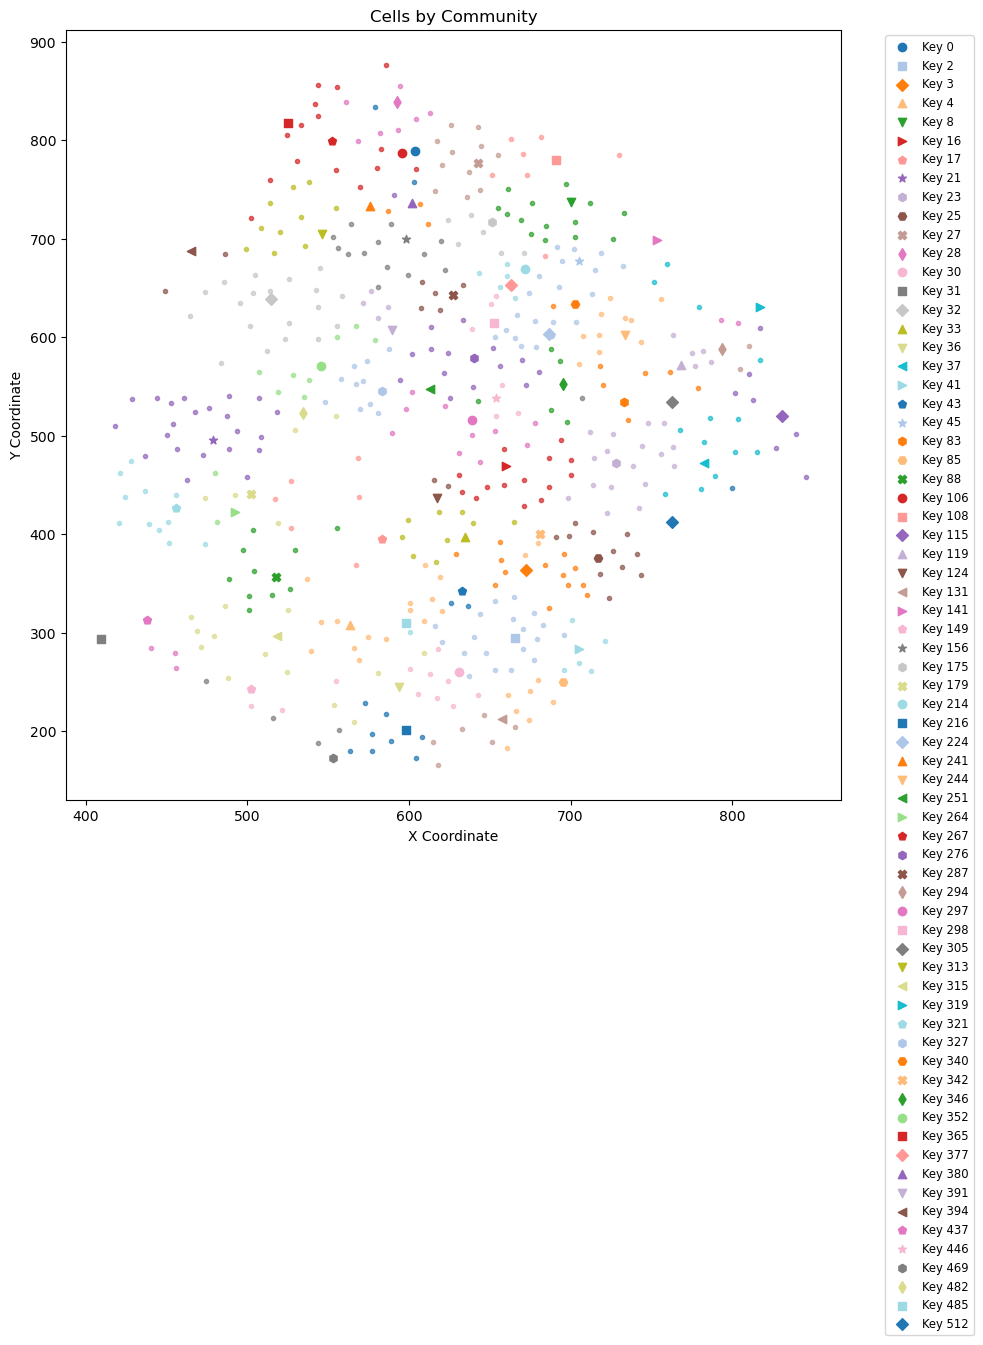

In [6]:
import matplotlib.pyplot as plt

# Define markers for keys
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']
colors = plt.cm.tab20.colors  # Use a colormap for colors

plt.figure(figsize=(10, 10))

for i, (key, value) in enumerate(community.items()):
    if value.size == 0:
        continue  # Skip empty communities
    marker = markers[i % len(markers)]  # Cycle through markers
    color = colors[i % len(colors)]  # Cycle through colors
    
    # Plot the key with a different shape
    plt.scatter(de_qu.cells_xy[key, 0], de_qu.cells_xy[key, 1], color=color, marker=marker, label=f'Key {key}')
    
    # Plot the values in the community with the same color
    plt.scatter(de_qu.cells_xy[value, 0], de_qu.cells_xy[value, 1], color=color, marker='.', alpha=0.7)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Cells by Community')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), fontsize='small')
# plt.tight_layout()
plt.show()

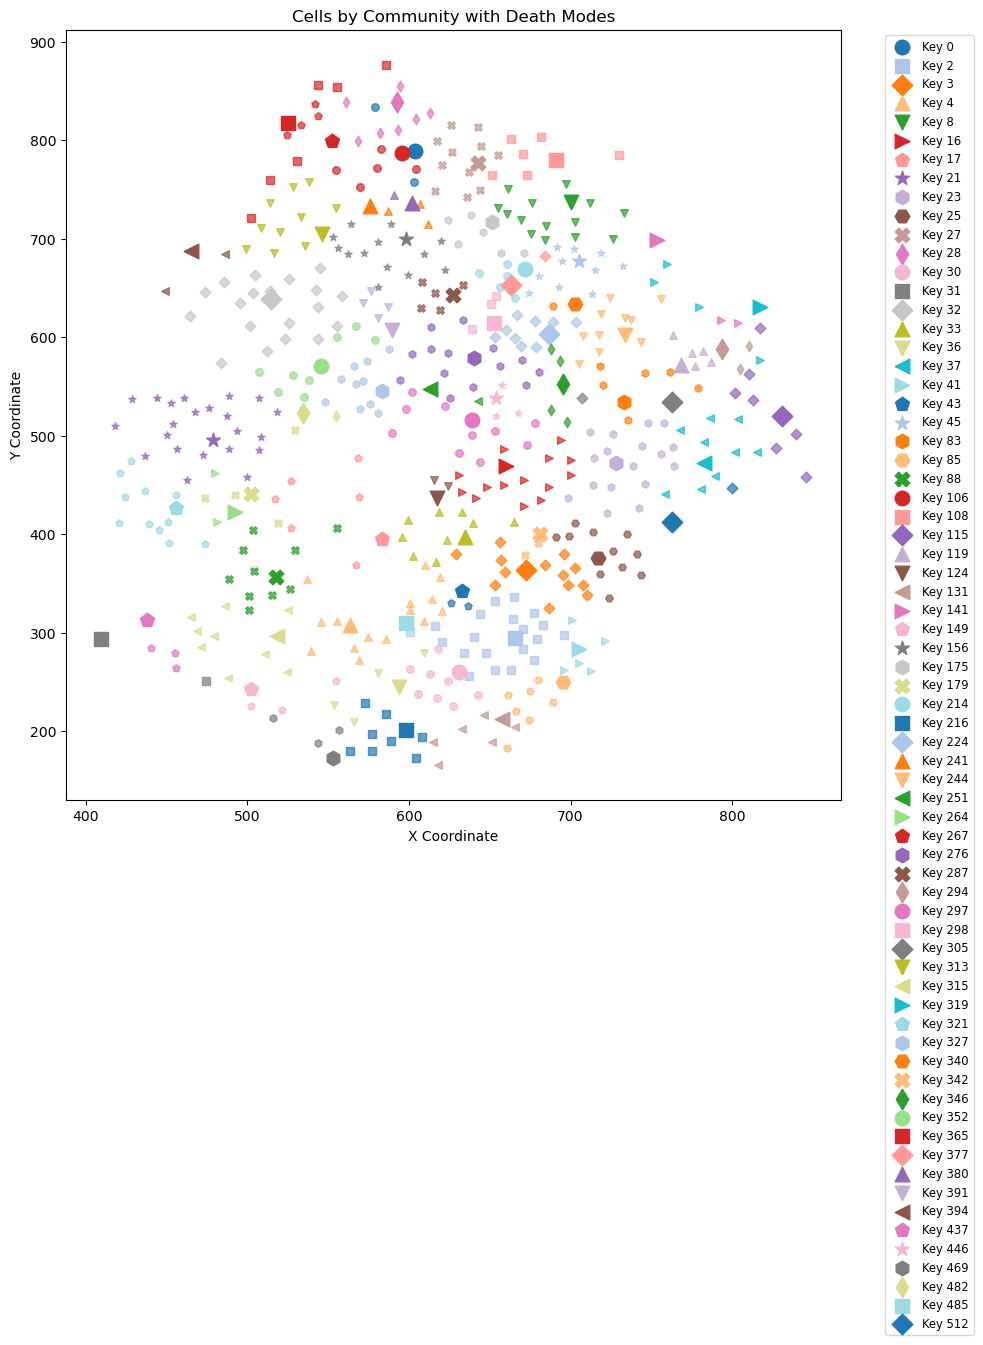

In [7]:
plt.figure(figsize=(10, 10))

# Define markers and colors
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']
colors = plt.cm.tab20.colors  # Use a colormap for colors

# Reverse transform death modes to their original labels
death_mode_labels = de_qu.le.inverse_transform(de_qu.death_modes.flatten())

for i, (key, value) in enumerate(community.items()):
    if value.size == 0:
        continue  # Skip empty communities
    
    marker = markers[i % len(markers)]  # Cycle through markers
    key_color = colors[i % len(colors)]  # Cycle through colors
    
    # Plot the key with a larger marker size
    plt.scatter(de_qu.cells_xy[key, 0], de_qu.cells_xy[key, 1], color=key_color, marker=marker, s=110, label=f'Key {key}')
    
    # Plot the values in the community with the same color and smaller marker size
    for val in value:
        val_color = key_color
        plt.scatter(de_qu.cells_xy[val, 0], de_qu.cells_xy[val, 1], color=val_color, marker=marker, s=30, alpha=0.7)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Cells by Community with Death Modes')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), fontsize='small')
# plt.tight_layout()
plt.show()

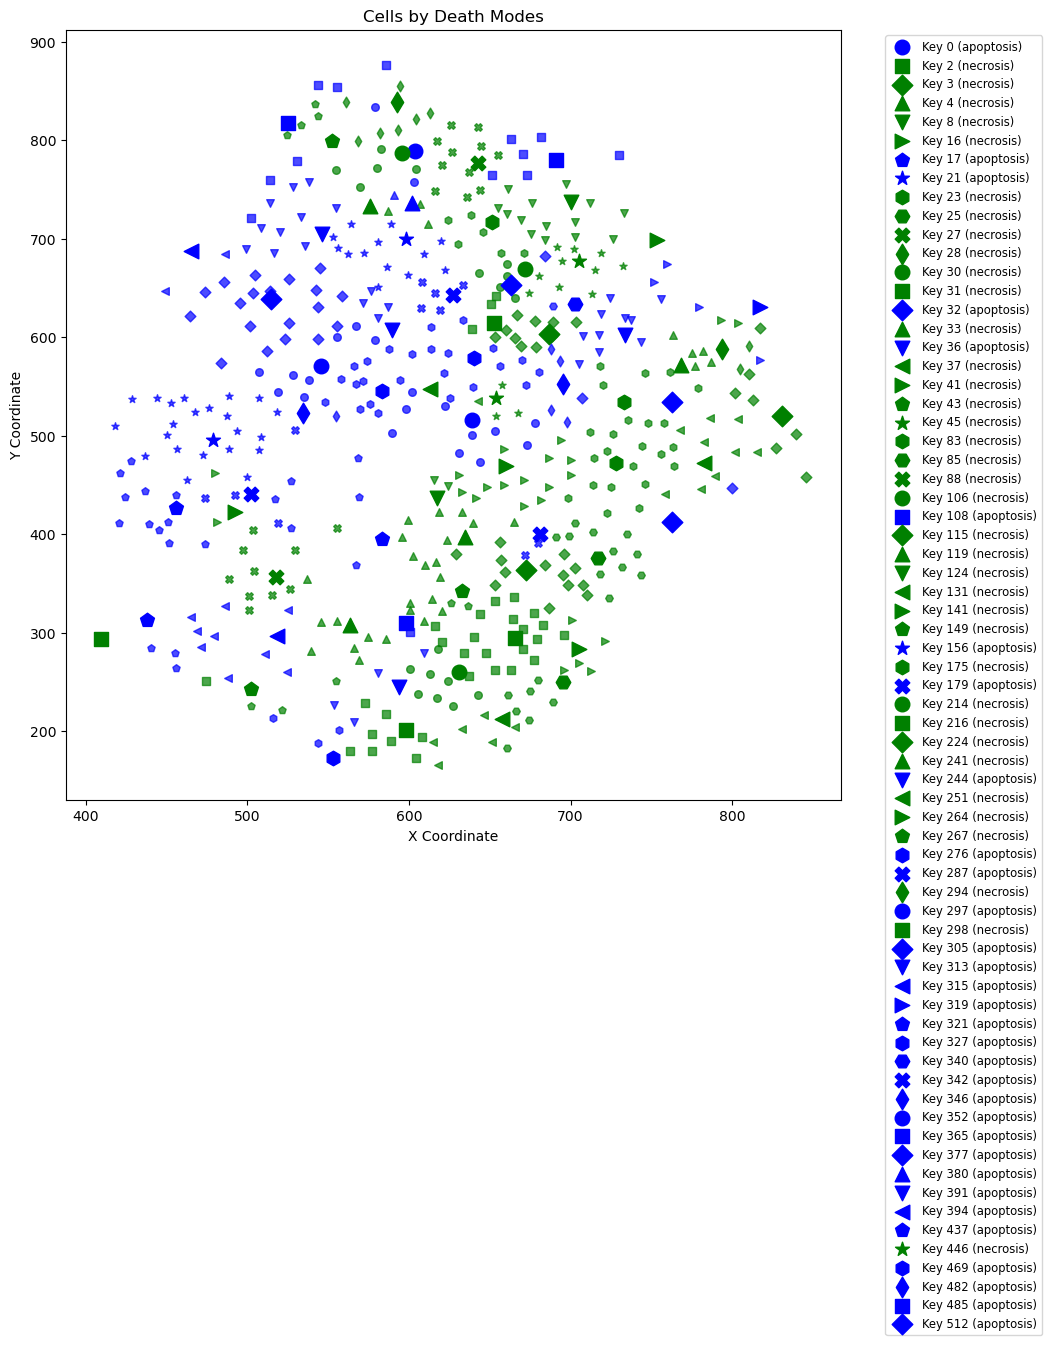

In [8]:
# Define a dictionary mapping death modes to colors
death_mode_colors = {
    'apoptosis': 'blue',
    'necrosis': 'green',
    'mixed': 'green',
    'unknown': 'black'
}

plt.figure(figsize=(10, 10))

for i, (key, value) in enumerate(community.items()):
    if value.size == 0:
        continue  # Skip empty communities
    
    # Determine marker for the community
    marker = markers[i % len(markers)]
    
    # Plot the key with its death mode color and larger marker size
    key_death_mode = death_mode_labels[key] if key < len(death_mode_labels) else 'unknown'
    key_color = death_mode_colors.get(key_death_mode, 'black')
    plt.scatter(de_qu.cells_xy[key, 0], de_qu.cells_xy[key, 1], color=key_color, marker=marker, s=110, label=f'Key {key} ({key_death_mode})')
    
    # Plot the values in the community with the same marker and their respective death mode colors
    for val in value:
        val_death_mode = death_mode_labels[val] if val < len(death_mode_labels) else 'unknown'
        val_color = death_mode_colors.get(val_death_mode, 'black')
        plt.scatter(de_qu.cells_xy[val, 0], de_qu.cells_xy[val, 1], color=val_color, marker=marker, s=30, alpha=0.7)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Cells by Death Modes')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), fontsize='small')
# plt.tight_layout()
plt.show()